<a href="https://colab.research.google.com/github/EmIbrahimovic/sp26_6_4110_hw_colabs/blob/main/mp4/mp04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project 4: Planning Under Uncertainty

In [1]:

# Setup matplotlib animation
import matplotlib
matplotlib.rc('animation', html='jshtml')


## Imports and Utilities

In [2]:

from typing import (Callable, Iterable, List, Sequence, Tuple, Dict, Optional,
                    Any, Union, Set, ClassVar, Type, TypeVar)

from abc import abstractmethod, ABC
import collections
import textwrap
import math
import functools
import itertools
import random
import dataclasses
import numpy as np
import heapq as hq

from functools import cached_property

import scipy.signal


def heatmap(data, ax=None, cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """
    import matplotlib.pylab as plt

    if ax is None:
        ax = plt.gca()

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    if cbar_kw is not None:
        cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
        cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(),
             rotation=-30,
             ha="right",
             rotation_mode="anchor")

    # Turn spines off and create white grid.
    for spine in ax.spines.values():
      spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1] + 1) - .5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - .5, minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im


def annotate_heatmap(im,
                     data=None,
                     valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None,
                     **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    import matplotlib.ticker

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max()) / 2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts


State = Any
Observation = Any
Action = Any


class Problem(ABC):
    """The abstract base class for either a path cost problem or a reward problem."""

    @property
    @abstractmethod
    def initial(self) -> State:
        ...

    @abstractmethod
    def actions(self, state: State) -> Iterable[Action]:
        """Returns the allowed actions in a given state.

        The result would typically be a list. But if there are many
        actions, consider yielding them one at a time in an iterator,
        rather than building them all at once.
        """
        ...

    @abstractmethod
    def step(self, state: State, action: Action) -> State:
        """Returns the next state when executing a given action in a given
        state.

        The action must be one of self.actions(state).
        """
        ...


class PathCostProblem(Problem):
    """An abstract class for a path cost problem, based on AIMA.

    To formalize a path cost problem, you should subclass from this and
    implement the abstract methods. Then you will create instances of
    your subclass and solve them with the various search functions.
    """

    @abstractmethod
    def goal_test(self, state: State) -> bool:
        """Checks if the state is a goal."""
        ...

    @abstractmethod
    def step_cost(self, state1: State, action: Action, state2: State) -> float:
        """Returns the cost incurred at state2 from state1 via action."""
        ...

    def h(self, state: State) -> float:
        """Returns the heuristic value, a lower bound on the distance to goal."""
        return 0


class POMDP(Problem):
    """A generative-model-based POMDP."""

    @property
    def discount(self) -> float:
        """The discount factor."""
        return 1.

    @property
    def horizon(self) -> int:
        """The planning horizon."""
        return np.inf

    @abstractmethod
    def terminal(self, state: State) -> bool:
        """If this state is terminating (absorbing state)."""
        return False

    @abstractmethod
    def reward(self, state1: State, action: Action, state2: State) -> float:
        """Returns the reward given at state2 from state1 via action."""
        ...

    @abstractmethod
    def get_observation(self, state: State) -> State:
        """Sample an observation from current state."""
        ...


class MDP(POMDP):
    """An generative-model-based MDP."""

    def get_observation(self, state: State) -> State:
        """An MDP is fully observable."""
        return state


class SearchFailed(ValueError):
    """Raise this exception whenever a search must fail."""
    pass


# A useful data structure for best-first search
BFSNode = collections.namedtuple("BFSNode",
                                 ["state", "parent", "action", "cost", "g"])


def run_best_first_search(
    problem: PathCostProblem,
    get_priority: Callable[[BFSNode], float],
    step_budget: int = 10000
) -> Tuple[List[State], List[Action], List[float], int]:
    """A generic heuristic search implementation.

    Depending on `get_priority`, can implement A*, GBFS, or UCS.

    The `get_priority` function here should determine the order
    in which nodes are expanded. For example, if you want to
    use path cost as part of this determination, then the
    path cost (node.g) should appear inside of get_priority,
    rather than in this implementation of `run_best_first_search`.

    Important: for determinism (and to make sure our tests pass),
    please break ties using the state itself. For example,
    if you would've otherwise sorted by `get_priority(node)`, you
    should now sort by `(get_priority(node), node.state)`.

    Args:
      problem: a path cost problem.
      get_priority: a callable taking in a search Node and returns the priority
      step_budget: maximum number of `problem.step` before giving up.

    Returns:
      state_sequence: A list of states.
      action_sequence: A list of actions.
      cost_sequence: A list of costs.
      num_steps: number of taken `problem.step`s. Must be less than or equal to `step_budget`.

    Raises:
      error: SearchFailed, if no plan is found.
    """
    num_steps = 0
    frontier = []
    reached = {}

    root_node = BFSNode(state=problem.initial,
                        parent=None,
                        action=None,
                        cost=None,
                        g=0)
    hq.heappush(frontier, (get_priority(root_node), problem.initial, root_node))
    reached[problem.initial] = root_node
    num_expansions = 0

    while frontier:
        pri, s, node = hq.heappop(frontier)
        # If reached the goal, return
        if problem.goal_test(node.state):
            return (*finish_plan(node), num_steps)

        num_expansions += 1
        # Generate successors
        for action in problem.actions(node.state):
            if num_steps >= step_budget:
                raise SearchFailed(
                    f"Failed to find a plan in {step_budget} steps")
            child_state = problem.step(node.state, action)
            num_steps += 1
            cost = problem.step_cost(node.state, action, child_state)
            path_cost = node.g + cost
            # If the state is already in explored or reached, don't bother
            if not child_state in reached or path_cost < reached[child_state].g:
                # Add new node
                child_node = BFSNode(state=child_state,
                                     parent=node,
                                     action=action,
                                     cost=cost,
                                     g=path_cost)
                priority = get_priority(child_node)
                hq.heappush(frontier, (priority, child_state, child_node))
                reached[child_state] = child_node
    raise SearchFailed(f"Frontier exhausted after {num_steps} steps")


def finish_plan(node: BFSNode):
    """Helper for run_best_first_search."""
    state_sequence = []
    action_sequence = []
    cost_sequence = []

    while node.parent is not None:
        action_sequence.insert(0, node.action)
        state_sequence.insert(0, node.state)
        cost_sequence.insert(0, node.cost)
        node = node.parent
    state_sequence.insert(0, node.state)

    return state_sequence, action_sequence, cost_sequence


def run_astar_search(problem: PathCostProblem, step_budget: int = 10000):
    """A* search.

    Use your implementation of `run_best_first_search`.
    """
    get_priority = lambda node: node.g + problem.h(node.state)
    return run_best_first_search(problem, get_priority, step_budget=step_budget)


@dataclasses.dataclass(frozen=False, eq=False)
class MCTStateNode:
    """Node in the Monte Carlo search tree, keeps track of the children states."""
    # For MDP, this is a state; for POMDP, this is an observation
    obs: Union[State, Observation]
    N: int
    horizon: int
    parent: Optional['MCTChanceNode']
    children: Dict['MCTChanceNode',
                   Action] = dataclasses.field(default_factory=dict)


@dataclasses.dataclass(frozen=False, eq=False)
class MCTChanceNode:
    U: float
    N: int
    parent: MCTStateNode
    children: Dict[State,
                   MCTStateNode] = dataclasses.field(default_factory=dict)


def ucb(n: MCTStateNode, C: float = 1.4) -> float:
    """UCB for a node, note the C argument"""
    return (np.inf if n.N == 0 else
            (n.U / n.N + C * np.sqrt(np.log(n.parent.N) / n.N)))


RolloutPolicy = Callable[[State], Action]


def random_rollout_policy(problem: MDP, state: State) -> Action:
    return random.choice(list(problem.actions(state)))


def run_mcts_search(problem: POMDP,
                    state: Optional[State] = None,
                    state_sampler: Iterable[State] = None,
                    horizon: Optional[int] = None,
                    C: float = np.sqrt(2),
                    iteration_budget: int = 100,
                    n_simulations: int = 10,
                    max_backup: bool = True,
                    rollout_policy: RolloutPolicy = None,
                    verbose: bool = False) -> Action:
    """A generic MCTS search implementation for MDP and POMDPs.

    For MDP, this is a standard MCTS implementation based on description in AIMA
    (with some additional features).
    For POMDP, this is an implementation of the POMCP algorithm.

    Args:
        problem: an MDP or POMDP.
        state: the initial state. If None, then `state_sampler` must be provided.
        state_sampler: an iterable of states. If None, then `state` must be provided. This is used to sample the initial state for POMCP.
        horizon: the horizon of the search. If None, then the horizon is set to the problem's horizon.
        C: the C parameter for UCB.
        iteration_budget: the maximum number of iterations.
        n_simulations: the number of simulations to run at each MCTS iteration. In AIMA,
            this is set 1, but in general, we run multiple simulations to reduce variance.
        max_backup: whether to use max backup or sum backup.
        rollout_policy: the rollout policy. If None, then the random rollout policy is used.
        verbose: whether to print debug information.

    Returns:
        action: the best action to take at the initial state according to the search.
    """
    if state is None:
        state = problem.initial

    if state_sampler is None:
        state_sampler = itertools.repeat(state)

    if horizon is None:
        horizon = problem.horizon

    if rollout_policy is None:
        rollout_policy = functools.partial(random_rollout_policy, problem)

    ucb_fixed_C = functools.partial(ucb, C=C)

    rewards = []

    def select(n: MCTStateNode, state: State) -> Tuple[MCTStateNode, State]:
        """select a leaf node in the tree."""
        if n.children:
            # Select the best child, break ties randomly
            children = list(n.children.keys())
            random.shuffle(children)
            ucb_pick: MCTChanceNode = max(children, key=ucb_fixed_C)
            act = n.children[ucb_pick]
            next_state = problem.step(state, act)
            rewards.append(problem.reward(state, act, next_state))
            next_obs = problem.get_observation(
                next_state)  # For MDP this is same as next_state
            if next_obs not in ucb_pick.children:
                new_leaf = MCTStateNode(next_obs,
                                        horizon=n.horizon - 1,
                                        parent=ucb_pick,
                                        N=0)
                ucb_pick.children[next_obs] = new_leaf
                return new_leaf, next_state
            return select(ucb_pick.children[next_obs], next_state)
        return n, state

    def expand(n: MCTStateNode, state: State) -> Tuple[MCTStateNode, State]:
        """expand the leaf node by adding all its children actions."""
        assert not n.children
        if n.horizon == 0 or problem.terminal(state):
            return n, state
        for action in problem.actions(state):
            new_chance_node = MCTChanceNode(parent=n, U=0, N=0)
            n.children[new_chance_node] = action
        chance_node, action = random.choice(list(n.children.items()))
        next_state = problem.step(state, action)
        rewards.append(problem.reward(state, action, next_state))
        next_obs = problem.get_observation(
            next_state)  # For MDP this is same as next_state
        new_node = MCTStateNode(next_obs,
                                N=0,
                                horizon=n.horizon - 1,
                                parent=chance_node)
        chance_node.children[next_obs] = new_node
        return new_node, next_state

    def simulate(node: MCTStateNode, state: State) -> float:
        """simulate the utility of current state by taking a rollout policy."""
        total_reward = 0
        disc = 1
        h = node.horizon
        while h > 0 and not problem.terminal(state):
            action = rollout_policy(state)
            next_state = problem.step(state, action)
            reward = problem.reward(state, action, next_state)
            total_reward += disc * reward
            state = next_state
            disc = disc * problem.discount
            h -= 1
        return total_reward

    def backup(state_node: MCTStateNode, value: float) -> None:
        """passing the utility back to all parent nodes."""
        state_node.N += 1
        if state_node.parent:
            # Need to include the reward on the action *into* n
            parent_chance_node = state_node.parent
            parent_state_node = parent_chance_node.parent
            r = rewards.pop()
            future_val = r + problem.discount * value
            parent_chance_node.U += future_val
            parent_chance_node.N += 1
            if max_backup:
                bk_val = max(0 if n.N == 0 else n.U / n.N
                             for n in parent_state_node.children)
            else:
                bk_val = future_val
            backup(parent_state_node, bk_val)

    state = next(state_sampler)
    root = MCTStateNode(obs=problem.get_observation(state),
                        horizon=horizon,
                        parent=None,
                        N=0)

    i = 0
    while i < iteration_budget:
        state = next(state_sampler)
        assert len(rewards) == 0
        leaf, state = select(root, state)
        child, state = expand(leaf, state)
        value = np.mean([simulate(child, state) for _ in range(n_simulations)])
        backup(child, value)
        i += 1

    children = list(root.children.keys())
    random.shuffle(children)
    act = root.children[max(children, key=lambda p: p.U / p.N)]
    if verbose:
        print(
            {
                act: (c.U / c.N if c.N > 0 else 0, c.N)
                for c, act in root.children.items()
            }, act)
    return act


@dataclasses.dataclass(frozen=True, eq=True, order=True)
class PickupProblemState:
    robot_loc: Tuple[int, int]
    carried_patient: bool


OneWayBlock = collections.namedtuple('OneWayBlock', ['loc', 'dest'])


@dataclasses.dataclass(frozen=True)
class PickupProblem(PathCostProblem):
    """A simple deterministic pickup problem in a grid.

    The robot starts at some location and can move up, down, left, or right.
    There is a patient at some location.
    The goal is to pick up the patient and drop them off at the hospital.
    The robot can only move to a location if there is a path from the robot's
    current location to the destination that does not pass through any roadblocks.
    """
    grid_shape: Tuple[int, int]

    initial_robot_loc: Tuple[int, int] = (0, 0)

    patient_loc: Tuple[int, int] = (4, 0)  # initial location of the patient
    hospital_loc: Tuple[int, int] = (0, 3)

    one_ways: List[OneWayBlock] = dataclasses.field(default_factory=list)

    grid_act_to_delta: ClassVar = {
        "up": (-1, 0),
        "down": (1, 0),
        "left": (0, -1),
        "right": (0, 1)
    }
    all_grid_actions: ClassVar = tuple(grid_act_to_delta.keys())

    @property
    def initial(self) -> State:
        return PickupProblemState(self.initial_robot_loc,
                                  self.initial_robot_loc == self.patient_loc)

    @cached_property
    def _one_way_set(self) -> Set[OneWayBlock]:
        """Set of one-way blocks. Helps with fast lookup."""
        return set(self.one_ways)

    def actions(self, state: PickupProblemState) -> Iterable[Action]:
        """Actions from the current state: move up, down, left, or right unless blocked."""
        (r, c) = state.robot_loc
        actions = []
        for act in self.all_grid_actions:
            dr, dc = self.grid_act_to_delta[act]
            new_r, new_c = r + dr, c + dc
            if (new_r in range(self.grid_shape[0]) and
                    new_c in range(self.grid_shape[1]) and
                    OneWayBlock(state.robot_loc,
                                (new_r, new_c)) not in self._one_way_set):
                actions.append(act)
        return actions

    def step(self, state: PickupProblemState,
             action: Action) -> PickupProblemState:
        """We automatically pick up patient if we're on that square."""
        (r, c) = state.robot_loc
        dr, dc = self.grid_act_to_delta[action]
        return PickupProblemState(
            (r + dr, c + dc),
            state.carried_patient or self.patient_loc == (r + dr, c + dc),
        )

    def step_cost(self, state1, action, state2) -> float:
        """Cost of taking an action in a state.

        Actually not used in this project, but we keep it here for completeness.
        """
        return 1.

    def goal_test(self, state: PickupProblemState) -> bool:
        """True if at hospital and holding patient."""
        return state.robot_loc == self.hospital_loc and state.carried_patient

    def render(self, state: PickupProblemState, ax=None):
        """Render the state as a grid."""
        import matplotlib.pyplot as plt
        if ax is None:
            ax = plt.gca()

        heatmap(np.zeros(self.grid_shape),
                ax=ax,
                cmap="YlOrRd",
                vmin=0,
                vmax=1,
                origin="upper")

        # Render the robot
        robot = plt.Circle(state.robot_loc[::-1], 0.5, color='blue')
        ax.add_patch(robot)

        # Render the patient
        patient_loc = (state.robot_loc
                       if state.carried_patient else self.patient_loc)
        patient = plt.Circle(patient_loc[::-1], 0.3, color='orange')
        ax.add_patch(patient)

        # Render the hospital
        plt.plot([self.hospital_loc[1]], [self.hospital_loc[0]],
                 marker='P',
                 color='r',
                 markersize=15)

        # Render the walls and one-way doors
        one_ways = set(self._one_way_set)
        while one_ways:
            one_way = one_ways.pop()
            rev = OneWayBlock(one_way.dest, one_way.loc)
            if rev in one_ways:
                one_ways.remove(rev)
                src, dst = one_way.loc, one_way.dest
                if src < dst:
                    dst, src = src, dst
                src, dst = np.array(src), np.array(dst)
                mid_pt = (src + dst) / 2
                delta = dst - src
                wall = plt.Rectangle(mid_pt[::-1] - delta / 2 +
                                     delta[::-1] * 0.05,
                                     delta[0] if delta[0] != 0 else 0.1,
                                     delta[1] if delta[1] != 0 else 0.1,
                                     color='black')
                ax.add_patch(wall)
            else:
                src, dst = np.array(one_way.loc), np.array(one_way.dest)
                mid_pt = (src + dst) / 2
                delta = dst - src
                base = mid_pt + delta * 0.07
                length = -delta * 0.2
                arrow = plt.arrow(base[1],
                                  base[0],
                                  length[1],
                                  length[0],
                                  width=0.2,
                                  length_includes_head=True,
                                  head_length=0.2,
                                  color='black')
                ax.add_patch(arrow)


conv2D = functools.partial(scipy.signal.convolve2d,
                           mode='same',
                           boundary='fill',
                           fillvalue=0)

FireGridT = np.ndarray  # boolean array


@dataclasses.dataclass(frozen=True)
class FireProcess:
    """A probabilistic model for the evolution of fire in a grid.

    At time step $t$, the probability of a cell being on fire is weighted probability
    of the neighboring cell being on fire at time step $t-1$.
    """

    initial_fire_grid: np.ndarray

    fire_weights: np.ndarray = dataclasses.field(
        default_factory=lambda: np.array([[0, 1, 0], [1, 4, 1], [0, 1, 0]]))
    attenuation: float = 1.0

    rng: np.random.Generator = dataclasses.field(
        default_factory=np.random.default_rng)

    @cached_property
    def normalized_fire_weights(self) -> np.ndarray:
        return self.attenuation * self.fire_weights / np.sum(self.fire_weights)

    def dist(self, fire_grid: FireGridT) -> np.ndarray:
        """Given the fire grid at time t, return a new grid with marginal distributions of fire for t + 1."""
        next_fire_dist = conv2D(fire_grid, self.normalized_fire_weights)
        return np.clip(next_fire_dist, 0, 1)  # clip for numerical stability

    def sample(self, fire_grid: FireGridT) -> FireGridT:
        """Given the fire grid at time t, return a new grid that's a sample from the distribution."""
        return self.rng.binomial(1, self.dist(fire_grid)).astype(bool)

    def render(self, fire_grid: FireGridT, ax=None):
        heatmap(fire_grid, ax=ax, cmap="YlOrRd", vmin=0, vmax=1, origin="upper")


@dataclasses.dataclass(frozen=True, eq=True)
class FireMDPState(PickupProblemState):
    """A state in the fire MDP extends the pickup problem state with a fire grid."""

    fire_grid: np.ndarray

    # Below we implement __eq__ and __hash__ to make FireMDPState hashable.
    def __eq__(self, other):
        if not isinstance(other, FireMDPState):
            return False
        return (self.robot_loc == other.robot_loc and
                self.carried_patient == other.carried_patient and
                np.all(self.fire_grid == other.fire_grid))

    def __hash__(self):
        return hash((super().__hash__(), self.fire_grid.tobytes()))


T = TypeVar('T', bound='FireProblemCommon')


@dataclasses.dataclass(frozen=True)
class FireProblemCommon:
    """Common code for the fire MDP and POMDP problems."""

    pickup_problem: PickupProblem
    fire_process: FireProcess

    _horizon: int = np.inf
    _discount: float = 0.999

    step_reward: float = 0.

    burn_reward: float = -1
    goal_reward: float = 1.

    @property
    def horizon(self):
        return self._horizon

    @property
    def discount(self):
        return self._discount

    @property
    def initial_robot_loc(self):
        return self.pickup_problem.initial_robot_loc

    def robot_burned(self, state) -> bool:
        return bool(state.fire_grid[state.robot_loc])

    def succeeded(self, state) -> bool:
        return self.pickup_problem.goal_test(state)

    def reward(self, state1, action, state2) -> float:
        if self.robot_burned(state2):
            return self.burn_reward
        if self.succeeded(state2):
            return self.goal_reward
        return self.step_reward

    def terminal(self, state) -> bool:
        return (self.robot_burned(state) or self.succeeded(state))

    @property
    def grid_shape(self):
        return self.pickup_problem.grid_shape

    @classmethod
    def from_str(cls: Type[T],
                 env_s: str,
                 fire_process_kargs: Optional[Dict[str, Any]] = None,
                 **kwargs) -> T:
        """Create a problem from a grid string.

        Legend:
            . = empty
            F = fire
            < = one way block (can go left)
            > = one way block (can go right)
            ^ = one way block (can go up)
            v = one way block (can go down)
            X = wall (two way block)
            R = robot
            P = patient
            H = hospital
        Each line must be the same length, and starts and ends with a `|`.
        Each character is separated by a space.

        Warning:
            The user needs to make ssure that no cell location is a dead end (due to roadblocks)
            since our `terminal` condition does not check for empty available actions.
        """
        if fire_process_kargs is None:
            fire_process_kargs = {}

        lines = env_s.splitlines()
        assert all(len(line) == len(lines[0]) for line in lines)
        assert all(line[0] == '|' and line[-1] == '|' for line in lines)
        # remove the first and last character of each line
        lines = [line[1:-1] for line in lines]
        # split each line into a list of characters
        lines = [line[::2] for line in lines]
        w = len(lines[0]) // 2 + 1
        h = len(lines) // 2 + 1
        robot_loc = None
        patient_loc = None
        hospital_loc = None
        fire_grid = np.zeros((h, w), dtype=bool)
        one_ways = []
        for i, line in enumerate(lines):
            i2 = i // 2
            if i % 2 == 0:
                for j, c in enumerate(line):
                    j2 = j // 2
                    if j % 2 == 0:
                        if c == 'F':
                            fire_grid[i2, j2] = True
                        elif c == 'R':
                            robot_loc = (i2, j2)
                        elif c == 'P':
                            patient_loc = (i2, j2)
                        elif c == 'H':
                            hospital_loc = (i2, j2)
                        else:
                            assert c == '.'
                    else:
                        if c in '<X':
                            one_ways.append(OneWayBlock((i2, j2), (i2, j2 + 1)))
                        if c in '>X':
                            one_ways.append(OneWayBlock((i2, j2 + 1), (i2, j2)))
            if i % 2 == 1:
                for j, c in enumerate(line[::2]):
                    if c in 'vX':
                        one_ways.append(
                            OneWayBlock(loc=(i2 + 1, j), dest=(i2, j)))
                    if c in '^X':
                        one_ways.append(
                            OneWayBlock(loc=(i2, j), dest=(i2 + 1, j)))

        if robot_loc is None:
            raise ValueError("No robot location specified")
        if patient_loc is None:
            raise ValueError("No patient location specified")
        if hospital_loc is None:
            raise ValueError("No hospital location specified")

        pickup_problem = PickupProblem(fire_grid.shape, robot_loc, patient_loc,
                                       hospital_loc, one_ways)
        fire_process = FireProcess(fire_grid, **fire_process_kargs)
        return cls(pickup_problem, fire_process, **kwargs)


@dataclasses.dataclass(frozen=True)
class FireMDP(FireProblemCommon, MDP):
    """The completely observable fire problem."""

    @property
    def initial(self) -> FireMDPState:
        return FireMDPState(*dataclasses.astuple(self.pickup_problem.initial),
                            self.fire_process.initial_fire_grid)

    def actions(self, state: State) -> Iterable[Action]:
        return self.pickup_problem.actions(state)

    def step(self, state: FireMDPState, action: Action) -> FireMDPState:
        return FireMDPState(
            *dataclasses.astuple(self.pickup_problem.step(state, action)),
            self.fire_process.sample(state.fire_grid))

    def render(self, state: FireMDPState, ax=None):
        self.pickup_problem.render(state, ax=ax)
        self.fire_process.render(state.fire_grid, ax=ax)


def get_problem(name: str) -> MDP:
    """Return a problem instance by name."""

    params = {
        "maze":
            dict(env_s="""\
                |R < . X . > H|
                |            X|
                |. X .   .   .|
                |        X   X|
                |. X .   . X .|
                |    X   ^    |
                |. X .   . X .|
                |    X   ^   ^|
                |P   . > . > .|
                """,
                 fire_process_kargs=dict(fire_weights=np.array([
                     [0, 1, 0],
                     [1, 10, 1],
                     [0, 1, 0],
                 ])),
                 _horizon=20),
        "just_wait":
            dict(env_s="""\
                |.   R   .   H|
                |X   v   X   ^|
                |. X . X .   .|
                |    v       ^|
                |. X . X .   .|
                |    v       ^|
                |. X . X .   .|
                |    v       ^|
                |F X . X F   .|
                |    v       ^|
                |. X . X .   F|
                |    v       ^|
                |. X . X .   .|
                |X   v   X   ^|
                |P   .   .   .|
                """,
                 fire_process_kargs=dict(fire_weights=np.array([
                     [0, 1, 0],
                     [1, 20, 1],
                     [0, 1, 0],
                 ]))),
        "the_circle":
            dict(env_s="""\
                |R   .   .   H|
                |    X   X   v|
                |. X .   . X .|
                |            v|
                |. X F   . X .|
                |            v|
                |. X F   . X .|
                |    X   X   v|
                |P   . < . < .|
                """,
                 fire_process_kargs=dict(fire_weights=np.array([
                     [0, 1, 0],
                     [1, 4, 1],
                     [0, 1, 0],
                 ]))),
        "the_choice":
            dict(
                env_s="""\
                |.   .   F   F   F   F|
                |.   X   X   X   X   X|
                |. X .   .   .   .   .|
                |X                    |
                |R > .   .   F   .   .|
                |v                    |
                |. X .   .   .   .   .|
                |v   X   X   X   X   v|
                |. X .   F   F   . X .|
                |v                   v|
                |. X F   .   .   . X .|
                |v                   v|
                |. X F   .   .   . X .|
                |v                   v|
                |. X F   F   .   . X .|
                |v   X   X   X   X   v|
                |. > . > H   P < . < .|
                """,
                fire_process_kargs=dict(fire_weights=np.array([
                    [0, 1, 0],
                    [1, 4, 1],
                    [0, 1, 0],
                ]),),
            )
    }

    if name not in params:
        raise ValueError(f"Unknown problem name: {name}")

    params[name]["env_s"] = textwrap.dedent(params[name]["env_s"])
    return FireMDP.from_str(**params[name])


class Agent:
    """An agent that can act in an MDP or POMDP.

    A derived agent must keep track of its own internal state.
    """

    def reset(self):
        """Reset the agent's internal state."""
        pass

    @abstractmethod
    def act(self, obs: Union[Observation, State]) -> Action:
        """Return the agent's action given an observation.
        For MDP agents, `obs` will be the complete state"""
        ...


@dataclasses.dataclass
class OpenLoopAgent(Agent):
    """Agent that just follows a fixed sequence of actions."""

    actions: Sequence[Action]

    t: int = dataclasses.field(default=0, init=False)

    def reset(self):
        self.t = 0

    def act(self, obs) -> Action:
        del obs  # observation is not used
        assert self.t < len(self.actions)
        a = self.actions[self.t]
        self.t += 1
        return self.actions


def run_agent_on_problem(problem: Union[MDP, POMDP],
                         agent: Agent,
                         verbose: bool = True
                        ) -> Tuple[Sequence[State], Sequence[Action], float]:
    """Runs the agent on the problem and returns the trajectory."""
    random.seed(6)
    np.random.seed(4110)

    agent.reset()
    state = problem.initial
    obs = problem.get_observation(state)
    state_sequence = [state]
    action_sequence = []
    total_reward = 0
    while not problem.terminal(state) and len(state_sequence) < problem.horizon:
        action = agent.act(obs)
        next_state = problem.step(state, action)
        reward = problem.reward(state, action, next_state)
        total_reward += reward * problem.discount**len(state_sequence)
        if verbose:
            print(
                f"Action={action} reward={reward} total_reward={total_reward}")
        obs = problem.get_observation(next_state)
        state = next_state
        action_sequence.append(action)
        state_sequence.append(state)
    return state_sequence, action_sequence, total_reward


def animate_trajectory(problem: Union[MDP, POMDP],
                       trajectory: Tuple[Sequence[State], Sequence[Action]]):
    """Visualizes a trajectory.

    Args:
        problem: The problem.
        trajectory: A tuple of state and action sequences.

    Returns:
        A matplotlib animation.
    """
    import matplotlib.pyplot as plt
    import matplotlib.animation

    state_sequence, action_sequence, *_ = trajectory

    fig, ax = plt.subplots()

    total_reward = 0.

    def animate(i):
        ax.clear()
        ax.set_aspect('equal')
        nonlocal total_reward
        if i == 0:
            total_reward = 0
            ax.set_title(f"Step {i}: begin, total_reward={total_reward:.2f}")
        elif i < len(state_sequence):
            action = action_sequence[i - 1]
            reward = problem.reward(state_sequence[i - 1], action,
                                    state_sequence[i])
            total_reward += reward * problem.discount**i
            ax.set_title(
                f"Step {i}: action={action}, "
                f"reward={reward:.2f}, total_reward={total_reward:.2f}")

        problem.render(state_sequence[i], ax=ax)

    anim = matplotlib.animation.FuncAnimation(fig,
                                              animate,
                                              frames=len(state_sequence),
                                              interval=500)
    return anim





## Determinized Min-cost Path Problem


### Utilities

In [3]:


@dataclasses.dataclass(frozen=True, eq=True, order=True)
class DeterminizedFireMDPState(PickupProblemState):
    """A state for the DeterminizedFireMDP.

    The state is a pair of the PickupProblemState and a time step $t$.
    """
    time: int = 0

### Implementation
Complete the implementation of `DeterminizedFireMDP`. In particular:
- Complete `fire_dist_at_time` to compute the marginal probability of each cell being on fire at time $t$, given the true fire state at time $0$.
- Using `fire_dist_at_time`, complete `step_cost`.
- Complete the heuristic function `h`.
- Complete `actions`, `step`, and `goal_test`.

In [4]:
@dataclasses.dataclass(frozen=True)
class DeterminizedFireMDP(PathCostProblem):
    """Determinized version of the fire MDP --- tries to find the solution path
    that is most likely to succeed.
    """
    pickup_problem: PickupProblem
    fire_process: FireProcess

    # Additional cost for each step.
    # Can be 0 but we might have 0-cost arcs if the success probability is 1.
    action_cost = 1e-6

    # Use this to cache precomputed fire distributions, so we don't have to recompute them.
    fire_dists_cache: Dict[int, np.ndarray] = dataclasses.field(
        init=False,
        default_factory=dict,
    )

    def __post_init__(self):
        assert (self.pickup_problem.grid_shape ==
                self.fire_process.initial_fire_grid.shape)

    @property
    def initial(self) -> DeterminizedFireMDPState:
        return DeterminizedFireMDPState(
            *dataclasses.astuple(self.pickup_problem.initial),
            time=0,
        )

    def actions(self, state: DeterminizedFireMDPState) -> Iterable[Action]:
        return self.pickup_problem.actions(state)

    def step(self, state: DeterminizedFireMDPState,
             action: Action) -> State:
        """We automatically pick up patient if we're on that square."""
        next_state = self.pickup_problem.step(state, action)
        return DeterminizedFireMDPState(next_state.robot_loc, next_state.carried_patient, state.time + 1)

    def goal_test(self, state: DeterminizedFireMDPState) -> bool:
        """True if at hospital and holding patient."""
        return self.pickup_problem.goal_test(state)

    def step_cost(self, state1: DeterminizedFireMDPState, action: Action,
                  state2: DeterminizedFireMDPState) -> float:
        """Induce a small action_cost and the negative log-likelihood of no fire."""
        return self.action_cost - np.log(1 - self.fire_dist_at_time(state2.time)[state2.robot_loc])

    def fire_dist_at_time(self, t: int) -> np.ndarray:
        """Return the marginal distribution of fire grid at time $t$."""
        if t not in self.fire_dists_cache:
            if t == 0:
                self.fire_dists_cache[t] = self.fire_process.initial_fire_grid.astype(float)
            else:
                self.fire_dists_cache[t] = self.fire_process.dist(self.fire_dist_at_time(t - 1))
        return self.fire_dists_cache[t]

    @staticmethod
    def _manhattan_distance(loc1: Tuple[int, int], loc2: Tuple[int, int]) -> int:
        return abs(loc1[0] - loc2[0]) + abs(loc1[1] - loc2[1])

    def h(self, state: DeterminizedFireMDPState) -> float:
        """heuristic based on the manhattan distance to the patient and hospital."""
        r_loc = state.robot_loc
        h_loc = self.pickup_problem.hospital_loc
        p_loc = self.pickup_problem.patient_loc

        r_p_loc = self._manhattan_distance(r_loc, p_loc) if not state.carried_patient else 0
        return (r_p_loc + self._manhattan_distance(p_loc, h_loc)) * self.action_cost

## Determinized Fire MDP Agent


### Implementation
Complete `FireMDPDeterminizedAStarAgent` by implementing the `determinized_problem` method. The rest of the agent is already implemented, including the call to `run_astar_search`.

In [5]:
@dataclasses.dataclass(frozen=True)
class FireMDPDeterminizedAStarAgent(Agent):
    """Agent that uses A* to plan a path to the goal in a determinized
    version of the problem. Does not need any internal state since we
    re-determinize the problem at each step.
    """

    problem: FireMDP
    step_budget: int = 10000

    def determinized_problem(self,
                             state: FireMDPState) -> DeterminizedFireMDP:
        """Returns a determinized approximation of the fire MDP."""
        pp = self.problem.pickup_problem
        new_pickup_problem = PickupProblem(pp.grid_shape,
                                           state.robot_loc,
                                           state.robot_loc if state.carried_patient else pp.patient_loc,
                                           pp.hospital_loc,
                                           pp.one_ways)

        fp = self.problem.fire_process
        new_fire_process = FireProcess(state.fire_grid,
                                       fp.fire_weights,
                                       fp.attenuation,
                                       fp.rng)

        return DeterminizedFireMDP(new_pickup_problem, new_fire_process)

    def act(self, state: FireMDPState) -> Action:
        problem = self.determinized_problem(state)
        try:
            plan = run_astar_search(problem, self.step_budget)
        except SearchFailed:
            print("Search failed, performing a random action")
            return random.choice(list(self.problem.actions(state)))
        return plan[1][0]

## Experiments

Use `run_agent_on_problem` and `animate_trajectory` to run your agent and visualize its behavior. See the written questions for specific environments and animations to submit.

Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total

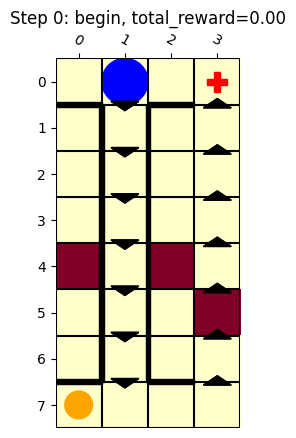

In [6]:
problem = get_problem("just_wait")
agent = FireMDPDeterminizedAStarAgent(problem)
trajectory = run_agent_on_problem(problem, agent)
anim = animate_trajectory(problem, trajectory)
from matplotlib.animation import FFMpegWriter
anim.save("mp4_just_wait.mp4", writer=FFMpegWriter(fps=5))
anim

Action=right reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=left reward=1.0 total_reward=0.986090636999001


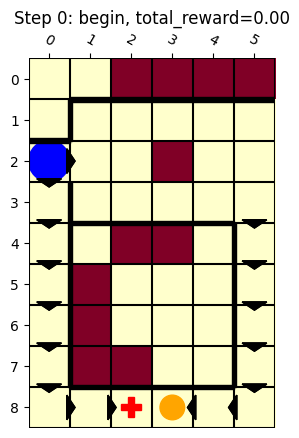

In [12]:
problem = get_problem("the_choice")
agent = FireMDPDeterminizedAStarAgent(problem)
trajectory = run_agent_on_problem(problem, agent)
anim = animate_trajectory(problem, trajectory)
anim.save("mp4_the_choice_determinized.mp4", writer=FFMpegWriter(fps=5))
anim

# Monte-Carlo Tree Search

Complete the implementation of `MCTSAgent`. Hint: You can pass in the `self.planning\_horizon` to `run\_mcts\_search`, to handle both infinite-horizon problems (by receding-horizon planning) and finite-horizon problems.

In [8]:
@dataclasses.dataclass
class MCTSAgent(Agent):
  '''Agent that uses Monte Carlo Tree Search to plan a path to the goal.

  The agent simply wraps `run_mcts_search`, and it should work for any MDP.
  '''

  problem: MDP

  # An optional receding horizon to use for the planning
  # If not provided, the problem must have a finite horizon
  receding_horizon: Optional[int] = 40

  C: float = np.sqrt(2)
  iteration_budget: int = 1000

  t: int = dataclasses.field(default=0, init=False)

  def __post_init__(self):
    if self.receding_horizon is None:
      assert self.problem.horizon != np.inf

  def reset(self):
    self.t = 0

  @property
  def planning_horizon(self) -> int:
    '''Returns the planning horizon for the current time step.'''
    if self.receding_horizon is None:
      return self.problem.horizon - self.t
    return self.receding_horizon

  def act(self, state: State) -> Action:
    '''Return the action to take at state.'''
    self.t += 1
    return run_mcts_search(self.problem, state, horizon=self.planning_horizon, C=self.C)

Action=right reward=0.0 total_reward=0.0
Action=up reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=up reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=up reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=up reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=up reward=0.0 total_reward=0.0
Action=down reward=0.0 total_reward=0.0
Action=up reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=left reward=0.0 total_reward=0.0
Action=right reward=0.0 total_reward=0.0
Acti

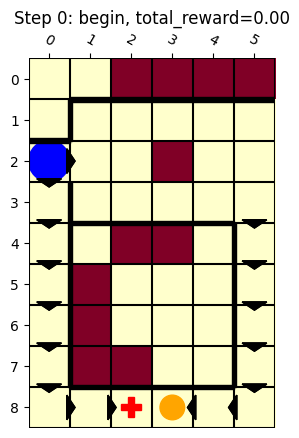

In [9]:
problem = get_problem("the_choice")
agent = MCTSAgent(problem)
trajectory = run_agent_on_problem(problem, agent)
anim = animate_trajectory(problem, trajectory)
anim.save("mp4_the_choice_mcts.mp4", writer=FFMpegWriter(fps=5))
anim